In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

classes = train_dataset.classes

100%|██████████| 170M/170M [00:03<00:00, 45.1MB/s]


In [6]:
class CNN_From_Scratch(nn.Module):
    def __init__(self):
        super(CNN_From_Scratch, self).__init__()

        # Convolution Layer 1
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        # Convolution Layer 2
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        # Max Pooling
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully Connected Layers
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.relu(self.conv1(x))
        x = self.pool(x)

        x = self.relu(self.conv2(x))
        x = self.pool(x)

        x = x.view(-1, 64 * 8 * 8)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN_From_Scratch().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [8]:
epochs = 10

train_losses = []
train_accuracies = []

for epoch in range(epochs):

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        # Forward Pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Loss: {epoch_loss:.4f} "
          f"Accuracy: {epoch_accuracy:.2f}%")

Epoch [1/10] Loss: 1.2784 Accuracy: 53.84%
Epoch [2/10] Loss: 0.8854 Accuracy: 69.12%
Epoch [3/10] Loss: 0.6902 Accuracy: 75.95%
Epoch [4/10] Loss: 0.5200 Accuracy: 81.73%
Epoch [5/10] Loss: 0.3621 Accuracy: 87.56%
Epoch [6/10] Loss: 0.2228 Accuracy: 92.49%
Epoch [7/10] Loss: 0.1355 Accuracy: 95.52%
Epoch [8/10] Loss: 0.0886 Accuracy: 97.13%
Epoch [9/10] Loss: 0.0739 Accuracy: 97.56%
Epoch [10/10] Loss: 0.0637 Accuracy: 97.90%


In [9]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test Accuracy:", 100 * correct / total)

Test Accuracy: 72.39


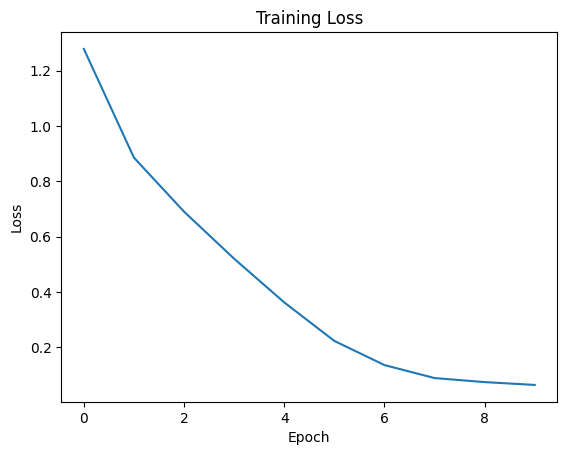

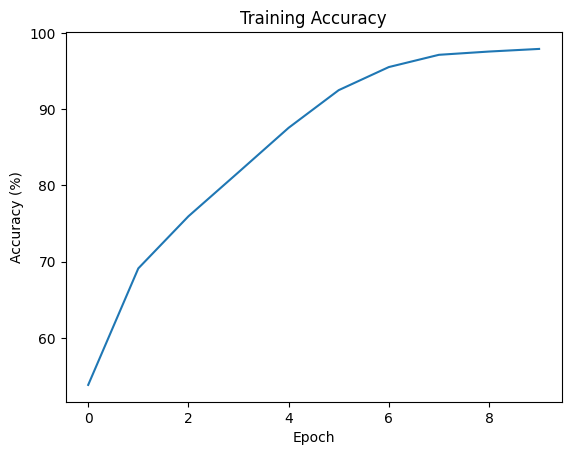

In [10]:
plt.figure()
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(train_accuracies)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.show()